# 01 - Análise Exploratoria (EDA)

## 1.0 Contexto de Problema

Baseado em uma estrutura de dados de vôos de linhas aéreas queremos criar um modelo preditivo que permita prever se um voo irá atrasar (modelo de classificação).
Para isso, será considerado atraso, vôos que chegarem a seus destinos 15 minutos ou mais do horário previsto que é o padrão de tolerância utilizado pelo FAA (Federal Aviation Admnistration).

__Referência:__ https://www.aspm.faa.gov/aspmhelp/index/Types_of_Delay.html

## 2.0 Setup e Carga

In [3]:
# Importando bibliotecas necessárias.
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Carregando data sets
df_flights = pd.read_csv('../data/raw/flights.csv')
df_airports = pd.read_csv('../data/raw/airports.csv')
df_airlines = pd.read_csv('../data/raw/airlines.csv')

/tmp/ipykernel_11572/2299264499.py:2: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv('../data/raw/flights.csv')


## 3.0 Visão Geral dos dados

In [5]:
# Informações da tabela flights.csv
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [6]:
# Informações da tabela airports.csv
df_airports.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    str    
 1   AIRPORT    322 non-null    str    
 2   CITY       322 non-null    str    
 3   STATE      322 non-null    str    
 4   COUNTRY    322 non-null    str    
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), str(5)
memory usage: 33.4 KB


In [7]:
# Informações da tabela airlines.csv
df_airlines.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   IATA_CODE  14 non-null     str  
 1   AIRLINE    14 non-null     str  
dtypes: str(2)
memory usage: 669.0 bytes


### 3.1 Resumo

**Tabela flights:**
- Linhas: 5.819.079 
- Colunas: 31 
- Uso de Memória: 1.3+ GB

**Tabela airports:**
- Linhas: 322 
- Colunas: 7 
- Uso de Memória: 17,7 kb

**Tabela airlines:**
- Linhas: 14 
- Colunas: 2 
- Uso de Memória: 356.0 bytes

**Relação entre tabelas:**
- flights['ORIGIN_AIRPORT'] & flights['Destination_AIRPORT'] --> airport['IATA_CODE'] 
- flights['AIRLINE'] --> airlines['IATA_CODE']

## 4.0 Análise da base principal (flights.csv)

### 4.1 Estruturae tipos de dados

Das informações da tabela flights.csv foi possível identificar os tipos de váriável de cada coluna.
É possível identificar algumas inconsistências entre o tipo adequado para a informação que deveria estar na coluna. Abaixo os tipos que foram encontrados e os valores que deveriam ser:

| id | Column | Dtype | Correct Dtype | Comment|
|:---|:---|:---|:---|:---|
| 0 | YEAR | int64 |  |
| 1 | MONTH | int64 |  |
| 2 | DAY | int64 |  |
| 3 | DAY_OF_WEEK | int64 |  |
| 4 | AIRLINE | str |  |
| 5 | FLIGHT_NUMBER | int64 | **str**| Esse valor é uma classe de identificação e não um número.|
| 6 | TAIL_NUMBER | str | str |
| 7 | ORIGIN_AIRPORT | object | ? |verificar |
| 8 | DESTINATION_AIRPORT | object | ? |verificar |
| 9 | SCHEDULED_DEPARTURE | int64 | int64 | necessita decompor em HH(int64) e MM(int64) para modelo |
| 10 | DEPARTURE_TIME | float64 | int64| será removida confome seção 4.5 |
| 11 | DEPARTURE_DELAY | float64 |  |
| 12 | TAXI_OUT | float64 | |
| 13 | WHEELS_OFF | float64 | |
| 14 | SCHEDULED_TIME | float64 |  |
| 15 | ELAPSED_TIME | float64 | |
| 16 | AIR_TIME | float64 | |
| 17 | DISTANCE | int64 | |
| 18 | WHEELS_ON | float64 | |
| 19 | TAXI_IN | float64 | |
| 20 | SCHEDULED_ARRIVAL | int64 | int64| necessita decompor em HH(int64) e MM(int64) para modelo |
| 21 | ARRIVAL_TIME | float64 | int64| será removida confome seção 4.5 |
| 22 | ARRIVAL_DELAY | float64 | |
| 23 | DIVERTED | int64 | |
| 24 | CANCELLED | int64 | |
| 25 | CANCELLATION_REASON | str | |
| 26 | AIR_SYSTEM_DELAY | float64 | |
| 27 | SECURITY_DELAY | float64 | |
| 28 | AIRLINE_DELAY | float64 | |
| 29 | LATE_AIRCRAFT_DELAY | float64 | |
| 30 | WEATHER_DELAY | float64 | |

### 4.2 Valores Faltantes (análise com hipóteses verificadas)

Nesta seção serão verificadas colunas que possuem celuas vazias. Será feita uma analise crítica e apontamento de achador e inconsistências.

In [8]:
# Verificação de somatória de celulas vazias
df_flights.isnull().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

Analisando o target do modelo ARRIVAL_DELAY, temos 105.071 celulas vazias, assim como ELAPSED_TIME e AIR_TIME, o que pode indicar vôos que não ocorreram.
Vamos verificar quantos voos estão classificados como CANCELLED e DIVERTED.

In [9]:
# Calculando somatória de vôos cancelados
df_flights['CANCELLED'].sum()

np.int64(89884)

In [10]:
# Calculando somátória de vôos desviados
df_flights['DIVERTED'].sum()

np.int64(15187)

In [11]:
# Somatória de cancelados e desviados

total_canceld_and_diverted = df_flights['CANCELLED'].sum() + df_flights['DIVERTED'].sum()
total_canceld_and_diverted

np.int64(105071)

Hipótese confirmada, Voos cancelados e desviados aparecem como vazios para o target ARRIVAL_DELAY. 
Sendo assim, uma vez que o modelo quer prever vôos atrasado e não cancelados ou desviados, podemos remover as linhas onde CANCELED == 1 e DIVERTED == 1.

Pode-se avaliar em outro modelo preditivo a ocorrência de cancelamentos e desvisos. 

Temos as 5 últimas colunas, AIR_SYSTEM_DELAY, SECURITY_DELAY, AIRLINE_DELAY, LATE_AIRCRAFT_DELAY e WEATHER_DELAY com o mesmo valor de células vazias. a Hipótese é de que são vôos que não tiveram atraso superior a 15 minutos. 
Para verificar, vamos checar a quantidade de vôos que atrasaram 15 minutos ou mais e subtrair o valor do número total de linhas e ver se chegamos ao valor de zeros dessas celulas.

In [12]:
# Calculo de vôos que atrasaram
total_arrival_delays = (df_flights['ARRIVAL_DELAY'] >= 15).sum()
total_arrival_delays

np.int64(1063439)

In [13]:
# Teste da Hipótese

print(len(df_flights) - total_arrival_delays)

4755640


Hipótese Confirmada. Esses valores nulos correspondem a voos que não tiveram atraso de chegada igual ou superior a 15 min — o que inclui voos pontuais, voos com atraso pequeno (<15 min), vôos cancelados e vOos desviados. De qualque maneira essas colunas serão removidas por leakage (discussão completa na seção 4.5).

Outra coluna que merece análise é SCHEDULED_TIME com 6 valores nulos que aparentemente podem ser erro. Temos duas opções sendo a primeira remover essas linhas, uma vez que a quantidade é muito pequena quando comparada com toda a base ou Calcula-la a partir da subtração de SCHEDULED_ARRIVEL e SCHEDULED_DEPARTURE, uma vez que esses não possuem valores nulos. 
Para esse trabalho vamos com a opção 1: Remover essas linhas.

### 4.3 Análise do target (ARRIVAL_DELAY)

Nesta seção iremos fazer uma analise mais detalhada do target ARRIVAL_DELAY. 
Inicialmente vamos verificar a descrição estatística da coluna removendo voos cancelados e desviados.

In [14]:
# Avaliação estatistica de ARRIVAL_DELAY

df_flights_clean = df_flights[(df_flights['CANCELLED'] == 0) & (df_flights['DIVERTED'] == 0)]
df_flights_clean['ARRIVAL_DELAY'].describe()


count    5.714008e+06
mean     4.407057e+00
std      3.927130e+01
min     -8.700000e+01
25%     -1.300000e+01
50%     -5.000000e+00
75%      8.000000e+00
max      1.971000e+03
Name: ARRIVAL_DELAY, dtype: float64

Da função describe(), é possível identificar que metade dos voos chegam adiantados pelo menos 5 minutos, e que 75% deles chegam adiantados ou com até 8 minutos de atraso, o que sugere que a maioria dos voos estão com atraso <= 15 min. 
Contúdo, pode se ver que a média de atrasos é de 4.4 minutos, sugerindo que há valores com atrasos altos que levantam o valor e isso pode ser confirmado pelo valor máximo de 1971 minutos.
Para uma análise de Classificação não haverá problema uma vez que outliers serão classificados apenas como atrasado, mas para analise de regressão será necessário remoção destes.

In [15]:
# Verificação da quantidade de atrasos segundo regra de negócio

(df_flights_clean['ARRIVAL_DELAY'] >= 15).value_counts(normalize = True)

ARRIVAL_DELAY
False    0.813889
True     0.186111
Name: proportion, dtype: float64

Considerando a proporção entre Vôos atrasados e não atrasados, temos como baseline de accurácea para o modelo 81,4%.

array([[<Axes: title={'center': 'ARRIVAL_DELAY'}>]], dtype=object)

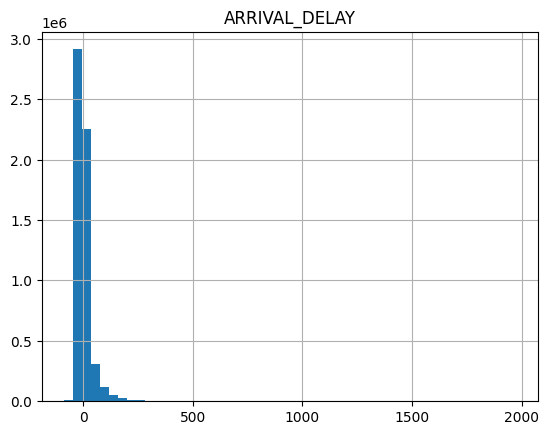

In [16]:
# Histograma da de ARRIVAL_DELAY
df_flights_clean.hist(column = 'ARRIVAL_DELAY', bins=50)

O histograma fica visualmente concentrado em uma única barra próxima ao zero devido aos outliers extremos — isso confirma o que já foi verificado com o Valor Máximo da coluna, o Histograma tem distribuição com cauda longa severa.
Agora verificaremos a distribuição dso dados por MONTH, DAY e DAY_OF_WEEK 

**Descobertas da Análise**
- ARRIVAL_DELAY tem distribuição assimétrica à direita (cauda longa), com mediana negativa (-5 min) e média positiva (+4,4 min) devido aos outliers.
- Outliers Extremos (max=1971 min) - irrelevante para classificação, problemático para regressão
- Após aplicar threshold de 15 min: ~18,6% atrasados  e ~81,4% não atrasados
- Classe Desbalanceadas exige split estratificado e métricas alem de acurácea para validação.

### 4.4 Análise das features candidatas

Para analise das features candidatas as dividirei em 4 grupos: Datas, Identificadores, Categóricas, Numéricas Relevantes, Horários

#### 4.4.1 - Datas (YEAR, MONTH, DAY, DAY_OF_WEEK)

In [17]:
# Avaliação estatistica

df_flights_clean[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK']].describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK
count,5714008.0,5.714008e+06,5.714008e+06,5.714008e+06
mean,2015.0,6.547799e+00,1.570759e+01,3.932643e+00
std,0.0,3.397421e+00,8.774394e+00,1.985967e+00
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00


É possível verificar que todos os Voos são do ano de 2015, sendo então uma feature que não agregaria nada ao modelo podendo ser dropada.
Vamos avaliar a distribuição dos dados em MONTH, DAY e DAY_OF_WEEK


In [18]:
# Verificação de distribuição de dados por MONTH

df_flights_clean['MONTH'].value_counts(normalize = True)

MONTH
7     0.090022
8     0.088197
6     0.086252
3     0.086128
5     0.085691
10    0.084508
4     0.083873
12    0.082204
11    0.080918
9     0.080881
1     0.079981
2     0.071344
Name: proportion, dtype: float64

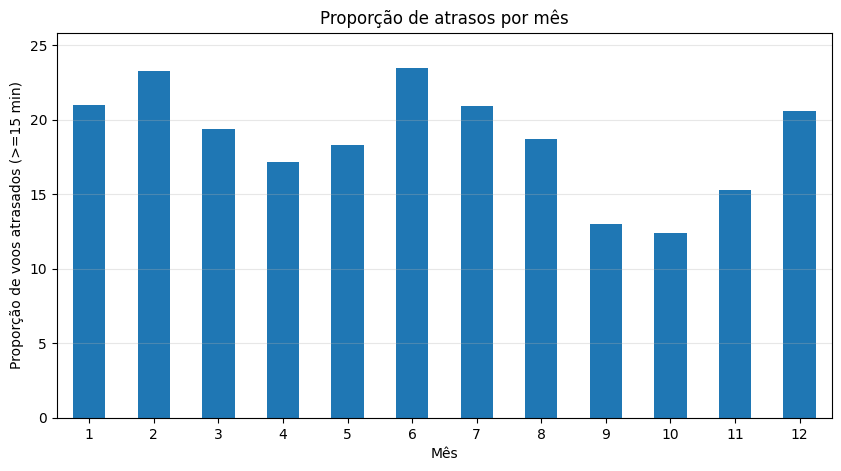

In [44]:
# Verificação da Relação de MONTH com ARRIVAL_DELAY
monthly_delay_rate = (df_flights_clean['ARRIVAL_DELAY'] >= 15).groupby(df_flights_clean['MONTH']).mean() * 100
monthly_delay_rate = monthly_delay_rate.sort_index().round(1)

plt.figure(figsize=(10,5))
monthly_delay_rate.sort_index().plot(kind='bar', color='C0')
plt.ylabel('Proporção de voos atrasados (>=15 min)')
plt.xlabel('Mês')
plt.title('Proporção de atrasos por mês')
plt.ylim(0, monthly_delay_rate.max()*1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

Verificando os dados é possível identificar sazonalidade para MONTH. A Diferença entre MIN de 12,4% e máx de 23,5% indica que é uma boa feature para o treinamento.

In [20]:
# Verificação de distribuição de dados por DAY

df_flights_clean['DAY'].value_counts(normalize = True)

DAY
13    0.033817
16    0.033683
20    0.033646
19    0.033517
8     0.033348
2     0.033342
22    0.033241
9     0.033192
23    0.033114
12    0.033093
6     0.033064
11    0.032961
18    0.032958
15    0.032934
4     0.032872
17    0.032858
3     0.032705
14    0.032602
28    0.032560
10    0.032533
21    0.032516
7     0.032510
27    0.032439
5     0.032344
25    0.032250
1     0.032127
26    0.031989
24    0.031868
29    0.031092
30    0.030926
31    0.017900
Name: proportion, dtype: float64

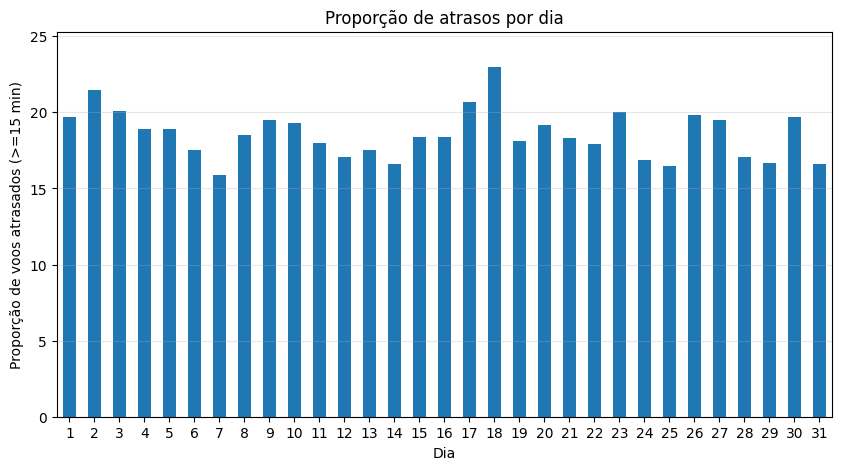

In [45]:
# Verificação da Relação de DAY com ARRIVAL_DELAY

day_delay_rate = (df_flights_clean['ARRIVAL_DELAY'] >= 15).groupby(df_flights_clean['DAY']).mean() * 100
day_delay_rate = day_delay_rate.sort_index().round(1)


plt.figure(figsize=(10,5))
day_delay_rate.sort_index().plot(kind='bar', color='C0')
plt.ylabel('Proporção de voos atrasados (>=15 min)')
plt.xlabel('Dia')
plt.title('Proporção de atrasos por dia')
plt.ylim(0, day_delay_rate.max()*1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

Verificando os dados é possível identificar variação relevante para DAY. A Diferença entre MIN de 15,9% e máx de 21,5% indica que é uma boa feature para o treinamento.

In [47]:
# Verificação de distribuição de dados por DAY_OF_WEEK

df_flights_clean['DAY_OF_WEEK'].value_counts(normalize = True)

DAY_OF_WEEK
4    0.150137
5    0.149000
3    0.147575
1    0.147321
2    0.144802
7    0.140454
6    0.120711
Name: proportion, dtype: float64

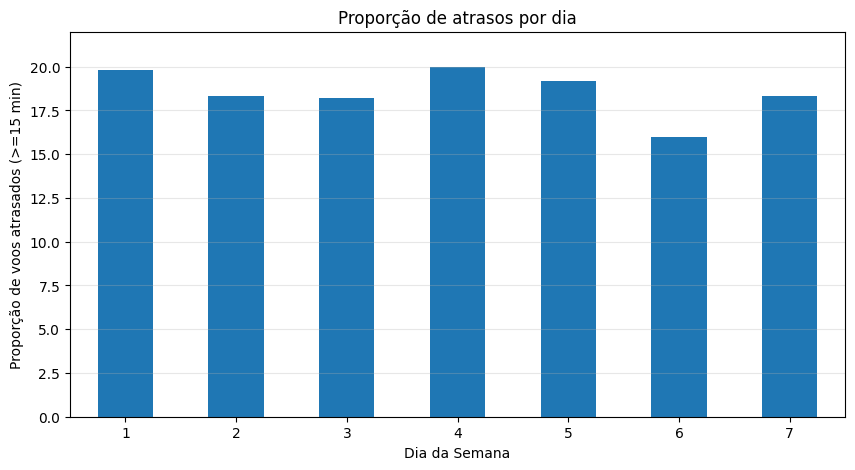

In [48]:
# Verificação da Relação de DAY_OF_WEEK com ARRIVAL_DELAY
day_delay_rate = (df_flights_clean['ARRIVAL_DELAY'] >= 15).groupby(df_flights_clean['DAY_OF_WEEK']).mean() * 100
day_delay_rate = day_delay_rate.sort_index().round(1)


plt.figure(figsize=(10,5))
day_delay_rate.sort_index().plot(kind='bar', color='C0')
plt.ylabel('Proporção de voos atrasados (>=15 min)')
plt.xlabel('Dia da Semana')
plt.title('Proporção de atrasos por dia')
plt.ylim(0, day_delay_rate.max()*1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

Verificando os dados é possível identificar sazonalidade para DAY_OF_WEEK. A Diferença entre MIN de 15,99% e máx de 20,01% indica que é uma boa feature para o treinamento.

#### 4.4.2 Identificadores (FLIGHT_NUMBER)

In [24]:
# Analise de cardinalidade

df_flights_clean['FLIGHT_NUMBER'].nunique()

6946

Há muitos valores individuais para essa feature. Outras features combrem melhor o que esta pode entregar ao modelo. Portanto essa será descartada.

#### 4.4.3 Categóricas (AIRLINE, ORIGIN, DESTINATION)

In [25]:
# Análise de Cardinalidade AIRLINE

df_flights_clean['AIRLINE'].nunique()


14

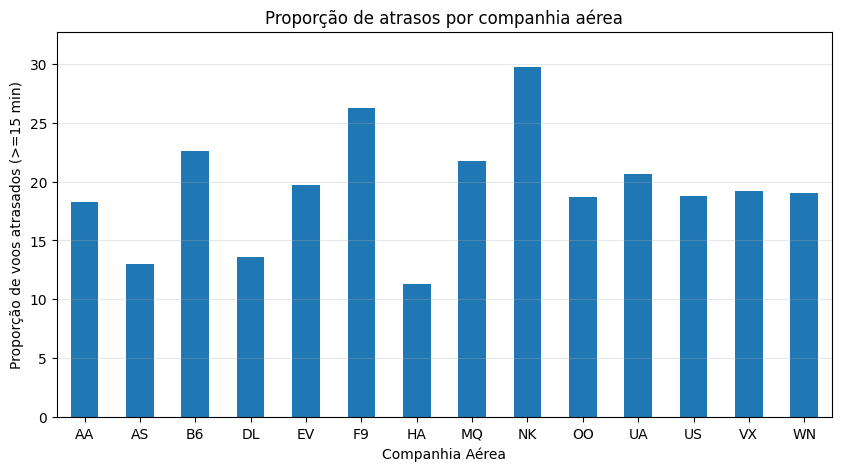

In [49]:
# Verificação da Relação de AIRLINE com ARRIVAL_DELAY
airline_delay_rate = (df_flights_clean['ARRIVAL_DELAY'] >= 15).groupby(df_flights_clean['AIRLINE']).mean() * 100
airline_delay_rate = airline_delay_rate.sort_index().round(1)


plt.figure(figsize=(10,5))
airline_delay_rate.sort_index().plot(kind='bar', color='C0')
plt.ylabel('Proporção de voos atrasados (>=15 min)')
plt.xlabel('Companhia Aérea')
plt.title('Proporção de atrasos por companhia aérea')   
plt.ylim(0, airline_delay_rate.max()*1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

Verificando os dados é possível identificar relevancia para AIRLINE. A Diferença entre MIN de ~11% e máx de ~29% indica que é uma boa feature para o treinamento.

In [27]:
# Análise TIpo de Cardinalidade ORIGIN_AIRPORT

df_flights_clean['ORIGIN_AIRPORT'].nunique()


929

Verificamos anteriormente que o tipo de dados dessa feature é object, o que quer dizer que temos tipos diferentes. 

In [28]:
# Verificando valores que ocorrem em ORIGIN_AIRPORT
df_flights_clean['ORIGIN_AIRPORT'].unique()


array(['ANC', 'LAX', 'SFO', 'SEA', 'LAS', 'DEN', 'SLC', 'PDX', 'FAI',
       'MSP', 'PHX', 'SJU', 'PBG', 'IAG', 'PSE', 'BQN', 'ORD', 'GEG',
       'HNL', 'ONT', 'MCO', 'BOS', 'HIB', 'ABR', 'DFW', 'MKE', 'IAH',
       'BNA', 'BRO', 'VPS', 'BOI', 'BJI', 'PHL', 'SBN', 'EUG', 'IAD',
       'BUF', 'PWM', 'JFK', 'CRP', 'PIA', 'FAT', 'SMF', 'AUS', 'MCI',
       'ATL', 'JAX', 'MFR', 'IDA', 'MSN', 'DCA', 'SAT', 'CHS', 'SBA',
       'IND', 'CLE', 'GSP', 'BDL', 'RIC', 'BFL', 'OMA', 'RDM', 'FLL',
       'CID', 'TPA', 'SYR', 'ROC', 'TYR', 'LAN', 'GSO', 'EWR', 'PBI',
       'RSW', 'OAK', 'PVD', 'RNO', 'PIT', 'ABQ', 'MIA', 'BWI', 'TUL',
       'LGA', 'LIT', 'MSY', 'OKC', 'ATW', 'PNS', 'MEM', 'TYS', 'MHT',
       'SAV', 'CLT', 'GRB', 'ABE', 'JAN', 'OAJ', 'FAR', 'ERI', 'LEX',
       'CWA', 'TTN', 'RDU', 'CVG', 'BHM', 'ACY', 'DTW', 'RAP', 'TUS',
       'EAU', 'DLH', 'FSD', 'INL', 'SPI', 'CLD', 'COD', 'CMH', 'PSC',
       'CPR', 'ACV', 'DAL', 'PAH', 'MRY', 'ESC', 'ISN', 'PSP', 'CAE',
       'STL', 'BTV',

In [29]:
# Verificação da ocorrencia de cada tipo de dado em ORIGIN_AIRPORT

df_flights_clean['ORIGIN_AIRPORT'].str.isnumeric().value_counts()

ORIGIN_AIRPORT
False    5231130
True       26881
Name: count, dtype: int64

Apenas ~0,47% dos dados são numéricos. 

In [30]:
# Análise TIpo de cardinalidade DESTINATION_AIRPORT

df_flights_clean['DESTINATION_AIRPORT'].nunique()


929

In [31]:
# Verificando valores que ocorrem em DESTINATION_AIRPORT
df_flights_clean['DESTINATION_AIRPORT'].unique()


array(['SEA', 'PBI', 'CLT', 'MIA', 'ANC', 'MSP', 'DFW', 'ATL', 'IAH',
       'PDX', 'MCI', 'FLL', 'ORD', 'HNL', 'PHX', 'EWR', 'JFK', 'MCO',
       'BOS', 'BDL', 'ITO', 'SFO', 'KOA', 'OGG', 'MYR', 'DTW', 'LIH',
       'DEN', 'SJU', 'LAX', 'BWI', 'IAD', 'BQN', 'BUF', 'LGA', 'HOU',
       'SLC', 'PHL', 'SJC', 'OAK', 'LGB', 'TPA', 'DCA', 'TTN', 'LAS',
       'RSW', 'BRD', 'STL', 'RKS', 'MBS', 'SNA', 'MEI', 'MDW', 'SAN',
       'RIC', 'OTZ', 'PIT', 'JAX', 'MSY', 'ONT', 'PSP', 'BUR', 'DAL',
       'CVG', 'SMF', 'RDU', 'BNA', 'AUS', 'DSM', 'BOI', 'ELP', 'TUS',
       'SCC', 'HPN', 'STT', 'MDT', 'RHI', 'SBP', 'MKE', 'JNU', 'CMH',
       'CLD', 'KTN', 'CAK', 'CLE', 'GPT', 'IND', 'SAT', 'SRQ', 'BTV',
       'CHS', 'DAY', 'TUL', 'SAV', 'COS', 'GJT', 'BZN', 'PUB', 'HRL',
       'HDN', 'MEM', 'GEG', 'ORH', 'SYR', 'ACY', 'LBB', 'JAC', 'BIL',
       'EUG', 'ASE', 'TVC', 'MTJ', 'OKC', 'PVD', 'HSV', 'CDC', 'GSO',
       'YUM', 'ABQ', 'TLH', 'EGE', 'BTR', 'MOB', 'FWA', 'BIS', 'MFR',
       'APN', 'BHM',

In [32]:
# Verificação da ocorrencia de cada tipo de dado em DESTINATION_AIRPORT

df_flights_clean['DESTINATION_AIRPORT'].str.isnumeric().value_counts()

DESTINATION_AIRPORT
False    5231130
True       26881
Name: count, dtype: int64

In [33]:
# Verificando se Dados numéricos de ORIGIN_AIRPORT e DESTINATION AIRPORT são da mesma linha

(df_flights_clean['ORIGIN_AIRPORT'].str.isnumeric() & df_flights_clean['DESTINATION_AIRPORT'].str.isnumeric()).value_counts()

False    5687127
True       26881
Name: count, dtype: int64

In [34]:
# Verificação da Relação de ORIGIN_AIRPORT com ARRIVAL_DELAY sem dados numéricos

df_flights_clean_v2 = df_flights_clean[(df_flights_clean['ORIGIN_AIRPORT'].str.isnumeric() == False)] 
(df_flights_clean_v2['ARRIVAL_DELAY'] >= 15).groupby(df_flights_clean_v2['ORIGIN_AIRPORT']).mean().describe()

count    322.000000
mean       0.175427
std        0.048391
min        0.019512
25%        0.151841
50%        0.175051
75%        0.197427
max        0.447368
Name: ARRIVAL_DELAY, dtype: float64

Foi possível verificar que sem os códigos numericos de ORIGIN, temos os 322 aeroportos que estão na base airports.CSV. 
Verificando a amplitute de min ~1,95% e max ~44,7%, provamos a relevância para o modelo. 

#### 4.4.4 Numéricas Relevantes (DISTANCE, SCHEDULED_TIME)

In [35]:
# Verificação de distribuição de dados por Distance

df_flights_clean_v2['DISTANCE'].describe()

count    5.231130e+06
mean     8.251291e+02
std      6.087307e+02
min      3.100000e+01
25%      3.730000e+02
50%      6.510000e+02
75%      1.066000e+03
max      4.983000e+03
Name: DISTANCE, dtype: float64

In [36]:
# Criando partições de distancia para posterior analise com ARRIVAL_DELAY

distance_labels = pd.cut(df_flights_clean_v2['DISTANCE'], bins = [0, 500, 1500, 3000, 5000], labels =['curto', 'médio', 'longo', 'extra'])

# Verificação da Relação de com ARRIVAL_DELAY
(df_flights_clean_v2['ARRIVAL_DELAY'] >= 15).groupby(distance_labels).mean()

DISTANCE
curto    0.187498
médio    0.195492
longo    0.189183
extra    0.241010
Name: ARRIVAL_DELAY, dtype: float64

É possivel verificar que o atraso sofre influencia com a distancia mas que em apenas distâncias muito grandes há uma incidencia maior.
Manteremos essa variável no modelo

In [37]:
# Verificação de distribuição de dados por SCHEDULED_TIME

df_flights_clean_v2['SCHEDULED_TIME'].describe()

count    5.231130e+06
mean     1.420045e+02
std      7.536162e+01
min      1.800000e+01
25%      8.600000e+01
50%      1.230000e+02
75%      1.740000e+02
max      7.180000e+02
Name: SCHEDULED_TIME, dtype: float64

In [38]:
# Criando partições de SCHEDULED_TIME para posterior analise com ARRIVAL_DELAY

scheduled_time_labels = pd.cut(df_flights_clean_v2['SCHEDULED_TIME'], bins = [0, 200, 400, 600, 800], labels =['curto', 'médio', 'longo', 'extra'])

# Verificação da Relação de com ARRIVAL_DELAY
(df_flights_clean_v2['ARRIVAL_DELAY'] >= 15).groupby(scheduled_time_labels).mean()

SCHEDULED_TIME
curto    0.191863
médio    0.190772
longo    0.234931
extra    0.219858
Name: ARRIVAL_DELAY, dtype: float64

De forma semelhante, verificamos que a distribuição de atrasos em função da SCHEDULE_TIME é parecido com a DISTANCE, o que faz sentido uma vez que o tempo de deslocamento é função da distância. 
Sendo assim, manteremos apenas a feature DISTANCE



#### 4.4.5 Horários (SCHEDULED_DEPARTURE, SCHEDULED_ARRIVAL)

In [39]:
# Analise de SCHEDULED_DEPARTURE

(df_flights_clean_v2['SCHEDULED_DEPARTURE'] // 100).describe()

count    5.231130e+06
mean     1.302699e+01
std      4.828134e+00
min      0.000000e+00
25%      9.000000e+00
50%      1.300000e+01
75%      1.700000e+01
max      2.300000e+01
Name: SCHEDULED_DEPARTURE, dtype: float64

In [40]:
# Verificação da Relação de com ARRIVAL_DELAY

(df_flights_clean_v2['ARRIVAL_DELAY'] >= 15).groupby(df_flights_clean_v2['SCHEDULED_DEPARTURE'] // 100).mean()

SCHEDULED_DEPARTURE
0     0.163374
1     0.191428
2     0.169970
3     0.178025
4     0.200765
5     0.074207
6     0.092770
7     0.115642
8     0.132774
9     0.146068
10    0.158262
11    0.168404
12    0.180827
13    0.195602
14    0.214424
15    0.221366
16    0.238265
17    0.252361
18    0.267376
19    0.270907
20    0.272037
21    0.252411
22    0.237729
23    0.198206
Name: ARRIVAL_DELAY, dtype: float64

É possível verificar que SCHEDULED_DEPARTURE influencia no TARGET pois tem amplitude alta. min ~7,4% por volta das 5h e max ~27,2% as 20h, portanto mantemos para o modelo.
Uma vez que decidimos ficar esta e DISTANCE, não faz sentido repetir a analise ou manter para SCHEDULED_ARRIVAL.

**Features finais para o Modelo:**

| Feature | Tipo | Tratamento necessário |
| :--- | :--- | :--- |
| `MONTH` | int | nenhum |
| `DAY` | int | nenhum |
| `DAY_OF_WEEK` | int | nenhum |
| `AIRLINE` | str | encoding (categoria $\rightarrow$ número) |
| `ORIGIN_AIRPORT` | str | encoding |
| `DESTINATION_AIRPORT` | str | encoding |
| `DISTANCE` | int | nenhum |
| `SCHEDULED_DEPARTURE` | int | decompor em HOUR + MINUTE |

**Removidas:** YEAR, FLIGHT_NUMBER, TAIL_NUMBER, SCHEDULED_TIME, SCHEDULED_ARRIVAL, e todas as colunas com leakage.

### 4.5 Identificação de risco de leakage

Leakage se refere a vazamento de dados para o modelo que se referem a informações que estariam disponíveis apenas após a ocorrência do que estamos tentando prever, no caso ARRIVAL_DELAY. Treinar o modelo com esses dados fariam com que ele atingisse métricas de desempenho quase perfeitas mas que na realidade não seria capaz de fazer a previsão. 

**Dados removidos com justificativa:** 

| Coluna | Tipo de leakage | Justificativa |
|:---|:---|:---|
| DEPARTURE_TIME | Tempo real do voo | Horário real de partida — só conhecido após o voo partir |
| DEPARTURE_DELAY | Métrica calculada a posteriori | Atraso de partida — só conhecido após o voo partir |
| TAXI_OUT | Tempo real do voo | Tempo de taxi até decolagem — só conhecido após decolar |
| WHEELS_OFF | Tempo real do voo | Horário de decolagem — só conhecido após decolar |
| ELAPSED_TIME | Tempo real do voo | Duração total real — só conhecido após o pouso |
| AIR_TIME | Tempo real do voo | Tempo no ar — só conhecido após o pouso |
| WHEELS_ON | Tempo real do voo | Horário do pouso — só conhecido após o pouso |
| TAXI_IN | Tempo real do voo | Tempo de taxi após o pouso — só conhecido após o pouso |
| ARRIVAL_TIME | Tempo real do voo | Horário real de chegada — só conhecido após o pouso |
| AIR_SYSTEM_DELAY | Motivo de atraso | Categorização do atraso — só conhecida após o voo |
| SECURITY_DELAY | Motivo de atraso | Categorização do atraso — só conhecida após o voo |
| AIRLINE_DELAY | Motivo de atraso | Categorização do atraso — só conhecida após o voo |
| LATE_AIRCRAFT_DELAY | Motivo de atraso | Categorização do atraso — só conhecida após o voo |
| WEATHER_DELAY | Motivo de atraso | Categorização do atraso — só conhecida após o voo |
| CANCELLATION_REASON | Motivo de cancelamento | Só existe para voos cancelados (que já decidimos remover) |

**ARRIVAL_DELAY** — não é leakage, é o target (vira a base do alvo binário)
**CANCELLED e DIVERTED** — não são leakage, são filtros (linhas removidas, não colunas)


## 6.0 Consolidação

Para o Modelo devemos ajustar o dataset flights.csv da seguinte forma:

1. Remover linhas onde: CANCELLED == 1, DIVERTED == 1, SCHEDULED_TIME == NaN, ORIGIN_AIRPORT.isnumeric() = TRUE

2. Colunas mantidas e tratamentos:

| Feature | Tipo | Tratamento necessário |
| :--- | :--- | :--- |
| `MONTH` | int | nenhum |
| `DAY` | int | nenhum |
| `DAY_OF_WEEK` | int | nenhum |
| `AIRLINE` | str | encoding (categoria $\rightarrow$ número) |
| `ORIGIN_AIRPORT` | str | encoding |
| `DESTINATION_AIRPORT` | str | encoding |
| `DISTANCE` | int | nenhum |
| `SCHEDULED_DEPARTURE` | int | decompor em HOUR + MINUTE |

3. Target: ARRIVAL_DELAY > = 15 -> 1, senão -> 0.

4. Volume Final Estimado :

Início: 5.819.079 linhas
−105.071 cancelados/desviados
−6 SCHEDULED_TIME nulo
−26.881 códigos numéricos
= ~5.687.121 linhas para treinar (~97,7% do dataset original)

Para esse modelo, não foram necessárias a utilização das tabelas auxiliares.

## 7.0 Próximos Passos

- Para um modelo de regressão, usaríamos as mesmas features, contúdo, seria necessário fazer o tratamento de Outliers.
- Para modelos futuros, poderíamos utilizar como target CANCELLED e DIVERTED.
- Seria possível enriquecer os dados de treinamento desse projeto utilizando os dados de latitude e longitude do dataset airports.csv. Decidiu-se nesse trabalho não inclui-los pois as features DISTANCE e AIRPORT entregaria informações similares ao modelo.
